# EOD discount curve — par yield, zero rate, discount factors

SQLite → `numeraire_viz` → matplotlib.

Pipeline in DB:
- **`par_curve_*`** — FRED par yields (`quoted_rate`)
- **`discount_curve_*`** — bootstrapped zero rates + discount factors

DB path: repo `db.sqlite3` or `NUMERAIRE_DB_PATH` / `.env` (relative paths from **repo root**).

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

from numeraire_viz import (
    default_db_path,
    list_discount_curve_dates,
    list_par_curve_dates,
    load_discount_curve,
    plot_curve_overview,
    plot_discount_factors,
    plot_yield_curve,
)

print("DB:", default_db_path())

DB: /opt/numeraire/dev/db.sqlite3


In [2]:
# --- parameters ---
CURVE_ID = "USD_TREASURY_PAR_FRED"
AS_OF = "2026-05-27"  # change me

disc_dates = list_discount_curve_dates(CURVE_ID)
par_dates = list_par_curve_dates(CURVE_ID)
print(f"Discount curve dates ({len(disc_dates)}):", disc_dates[-5:])
print(f"Par curve dates ({len(par_dates)}):", par_dates[-5:])
if AS_OF not in disc_dates:
    raise ValueError(f"{AS_OF!r} not in discount_curve_eod; pick one of the dates above.")

Discount curve dates (1): ['2026-05-27']
Par curve dates (1): ['2026-05-27']


In [3]:
points, disc_hdr, par_hdr = load_discount_curve(AS_OF, CURVE_ID)

display(pd.DataFrame([disc_hdr]).T.rename(columns={0: "discount_curve_eod"}))
display(pd.DataFrame([par_hdr]).T.rename(columns={0: "par_curve_eod"}))

table = points[
    [
        "tenor",
        "time_years",
        "quoted_rate",
        "zero_rate",
        "discount_factor",
        "instrument_type",
        "fred_series_id",
    ]
].copy()
table["quoted_rate_pct"] = (table["quoted_rate"] * 100).map(lambda x: f"{x:.3f}%")
table["zero_rate_pct"] = (table["zero_rate"] * 100).map(lambda x: f"{x:.3f}%")
table["discount_factor"] = table["discount_factor"].map(lambda x: f"{x:.6f}")
display(table)

,discount_curve_eod
curve_id,USD_TREASURY_PAR_FRED
as_of,2026-05-27
source_par_curve_id,USD_TREASURY_PAR_FRED
source_par_as_of,2026-05-27
currency,USD
day_count,Actual365Fixed
interpolation_method,linear_zero_rate
bootstrap_engine,deposit_swap_v1
par_curve_kind,treasury_par_fred
par_source,FRED


,par_curve_eod
curve_id,USD_TREASURY_PAR_FRED
as_of,2026-05-27
curve_kind,treasury_par_fred
source,FRED
currency,USD
day_count,Actual365Fixed


,tenor,time_years,quoted_rate,zero_rate,discount_factor,instrument_type,fred_series_id,quoted_rate_pct,zero_rate_pct
0,1M,0.082192,0.0372,0.037143,0.996952,deposit,DGS1MO,3.720%,3.714%
1,3M,0.249315,0.0368,0.036632,0.990909,deposit,DGS3MO,3.680%,3.663%
2,6M,0.498630,0.0379,0.037546,0.981452,deposit,DGS6MO,3.790%,3.755%
3,1Y,1.000000,0.0380,0.037296,0.963391,deposit,DGS1,3.800%,3.730%
4,2Y,2.000000,0.0400,0.039657,0.923751,swap,DGS2,4.000%,3.966%
5,3Y,3.000000,0.0409,0.040561,0.885429,swap,DGS3,4.090%,4.056%
6,5Y,5.000000,0.0417,0.041372,0.813134,swap,DGS5,4.170%,4.137%
7,7Y,7.000000,0.0432,0.042993,0.740113,swap,DGS7,4.320%,4.299%
8,10Y,10.000000,0.0448,0.044781,0.639023,swap,DGS10,4.480%,4.478%


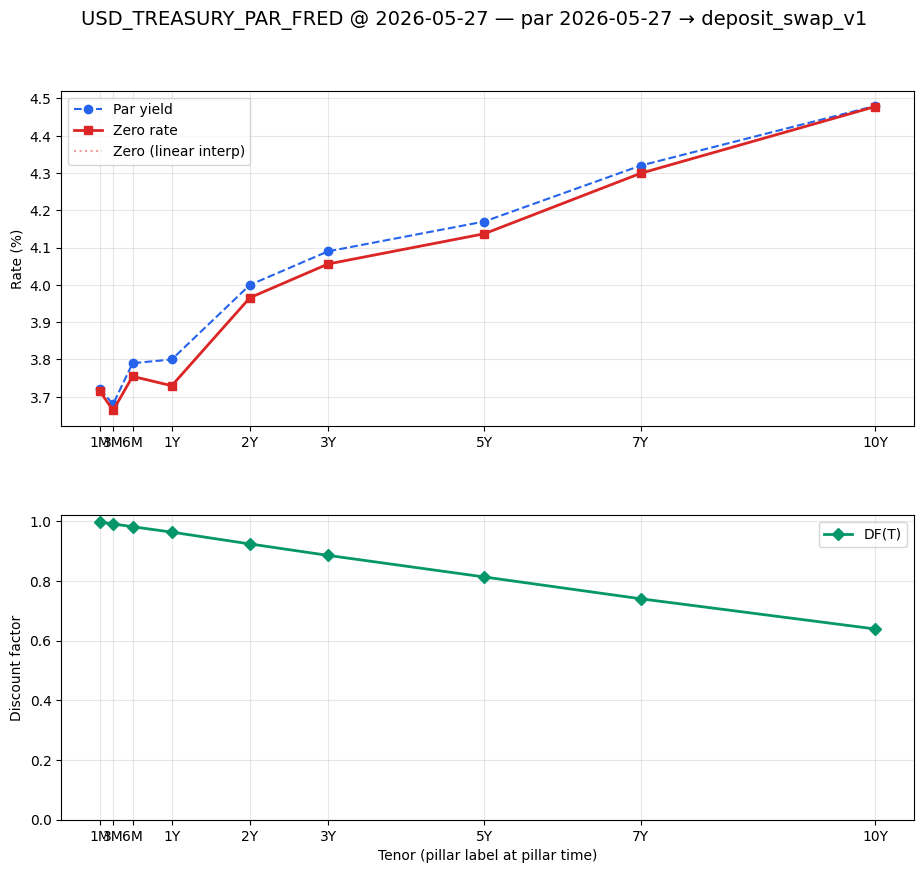

In [4]:
fig = plot_curve_overview(points, discount_header=disc_hdr, par_header=par_hdr)
plt.show()

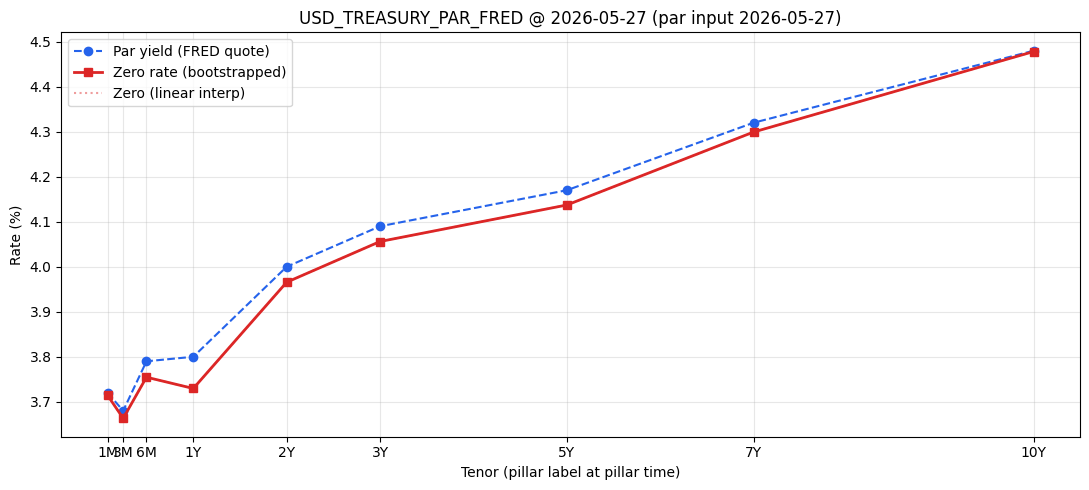

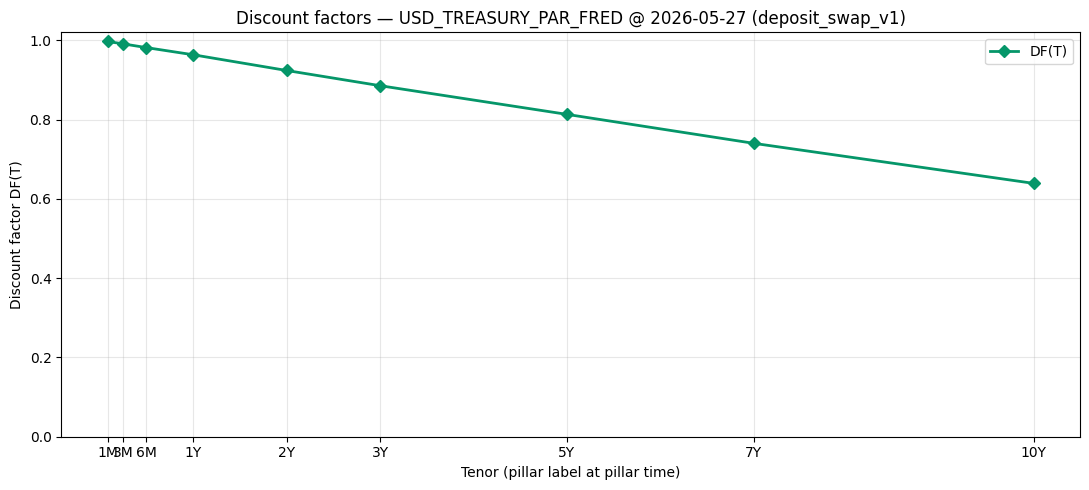

In [5]:
fig = plot_yield_curve(points, discount_header=disc_hdr)
plt.show()

fig = plot_discount_factors(points, discount_header=disc_hdr)
plt.show()